# NYC Childcare Desert Optimization
## IEOR E4004 Spring 2026 — Course Project I

**Goal:** Eliminate childcare deserts in all NYC zipcodes through optimal facility expansion and construction.

---

## Section 1: Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
from math import radians, sin, cos, sqrt, asin
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "../data/raw/"
# New facility: (total_slots, slots_0_5, fixed_cost)
NEW_FAC = {'S': (100, 50, 65_000), 'M': (200, 100, 95_000), 'L': (400, 200, 115_000)}
EQUIP_COST_PER_SLOT = 100  # extra $/slot for 0-5 children
MIN_DIST = 0.06            # miles, Problem II distance constraint

print("Imports successful.")
print(f"CVXPY version: {cp.__version__}")
print(f"Available solvers: {cp.installed_solvers()}")

Imports successful.
CVXPY version: 1.8.1
Available solvers: ['CLARABEL', 'GUROBI', 'HIGHS', 'OSQP', 'SCIPY', 'SCS']


## Section 2: Data Loading & Cleaning

In [2]:
# ── Load raw CSVs ──────────────────────────────────────────────────────────────
fac_raw   = pd.read_csv(DATA_DIR + "child_care_regulated_nyc.csv")
pop_raw   = pd.read_csv(DATA_DIR + "population_nyc.csv")
inc_raw   = pd.read_csv(DATA_DIR + "avg_individual_income_nyc.csv")
emp_raw   = pd.read_csv(DATA_DIR + "employment_rate_nyc.csv")
potential = pd.read_csv(DATA_DIR + "potential_locations_nyc.csv")

print(f"Raw facilities:        {len(fac_raw):,} rows")
print(f"Population zipcodes:   {pop_raw['zipcode'].nunique()}")
print(f"Income zipcodes:       {inc_raw['zipcode'].nunique()}")
print(f"Employment zipcodes:   {emp_raw['zipcode'].nunique()}")
print(f"Potential locations:   {len(potential):,} rows, {potential['zipcode'].nunique()} unique zips")

Raw facilities:        7,740 rows
Population zipcodes:   211
Income zipcodes:       179
Employment zipcodes:   179
Potential locations:   31,100 rows, 311 unique zips


In [3]:
# ── Filter active facilities ───────────────────────────────────────────────────
active_statuses = ['Registration', 'License']
facilities = fac_raw[
    fac_raw['facility_status'].isin(active_statuses) &
    (fac_raw['total_capacity'] > 0)
].copy()
print(f"Active facilities with capacity > 0: {len(facilities):,}")

# ── Impute missing lat/lon ─────────────────────────────────────────────────────
missing_coords = facilities['latitude'].isna() | facilities['longitude'].isna()
print(f"Facilities with missing lat/lon: {missing_coords.sum()}")

# Median lat/lon from same-zip facilities
zip_medians = facilities.dropna(subset=['latitude','longitude']).groupby('zipcode')[['latitude','longitude']].median()

# Median lat/lon from potential_locations
pot_medians = potential.groupby('zipcode')[['latitude','longitude']].median()

def impute_coords(row):
    if not (pd.isna(row['latitude']) or pd.isna(row['longitude'])):
        return row['latitude'], row['longitude']
    z = row['zipcode']
    if z in zip_medians.index:
        return zip_medians.loc[z, 'latitude'], zip_medians.loc[z, 'longitude']
    if z in pot_medians.index:
        return pot_medians.loc[z, 'latitude'], pot_medians.loc[z, 'longitude']
    return np.nan, np.nan

coords = facilities.apply(impute_coords, axis=1)
facilities['latitude']  = [c[0] for c in coords]
facilities['longitude'] = [c[1] for c in coords]

before = len(facilities)
facilities = facilities.dropna(subset=['latitude','longitude'])
print(f"Dropped {before - len(facilities)} facilities still missing coords. Remaining: {len(facilities):,}")

Active facilities with capacity > 0: 7,712
Facilities with missing lat/lon: 169
Dropped 0 facilities still missing coords. Remaining: 7,712


In [4]:
# ── Compute 0-5 capacity proxy ─────────────────────────────────────────────────
# For FDC/GFDC: use children_capacity; for SACC: use preschool_capacity
facilities['cap_0_5'] = np.where(
    facilities['program_type'] == 'SACC',
    facilities['preschool_capacity'],
    facilities['children_capacity']
)

# ── Aggregate per zip ─────────────────────────────────────────────────────────
zip_slots = facilities.groupby('zipcode').agg(
    existing_total=('total_capacity', 'sum'),
    existing_0_5=('cap_0_5', 'sum')
).reset_index()

print(f"Zips with existing facilities: {len(zip_slots)}")
print(zip_slots.describe())

Zips with existing facilities: 179
            zipcode  existing_total  existing_0_5
count    179.000000      179.000000    179.000000
mean   10801.497207     1773.748603    389.329609
std      575.177846     1511.200330    551.789650
min    10001.000000       16.000000      0.000000
25%    10291.500000      600.000000     65.000000
50%    11106.000000     1444.000000    192.000000
75%    11359.000000     2553.500000    450.000000
max    11694.000000     6984.000000   2895.000000


In [5]:
# ── Build base zip_df: population + employment + income (inner join) ───────────
pop = pop_raw[['zipcode', 'Total', '-5', '6-12']].copy()
pop.columns = ['zipcode', 'pop_total', 'pop_0_5', 'pop_6_12']
pop['pop_0_12'] = pop['pop_0_5'] + pop['pop_6_12']

inc = inc_raw[['zipcode', 'average income']].copy()
emp = emp_raw[['zipcode', 'employment rate']].copy()

zip_df = pop.merge(emp, on='zipcode', how='inner').merge(inc, on='zipcode', how='inner')
print(f"Inner join (pop + emp + inc): {len(zip_df)} zipcodes")

Inner join (pop + emp + inc): 179 zipcodes


In [6]:
# ── Add zipcode 11249 via KNN imputation ───────────────────────────────────────
TARGET_ZIP = 11249

if TARGET_ZIP not in zip_df['zipcode'].values:
    # Get centroid of 11249 from potential_locations
    pot_centroids = potential.groupby('zipcode')[['latitude','longitude']].mean().reset_index()
    
    if TARGET_ZIP in pot_centroids['zipcode'].values:
        tgt = pot_centroids[pot_centroids['zipcode'] == TARGET_ZIP].iloc[0]
        tgt_lat, tgt_lon = tgt['latitude'], tgt['longitude']
        
        # Centroids for zips already in zip_df
        base_centroids = pot_centroids[pot_centroids['zipcode'].isin(zip_df['zipcode'])].copy()
        base_centroids['dist'] = np.sqrt(
            (base_centroids['latitude'] - tgt_lat)**2 +
            (base_centroids['longitude'] - tgt_lon)**2
        )
        nearest10 = base_centroids.nsmallest(10, 'dist')
        neighbors = zip_df[zip_df['zipcode'].isin(nearest10['zipcode'])].copy()
        neighbors = neighbors.merge(nearest10[['zipcode','dist']], on='zipcode')
        
        # Weighted average (weight = 1/dist)
        neighbors['weight'] = 1.0 / (neighbors['dist'] + 1e-9)
        w = neighbors['weight'].values
        imp_emp = np.average(neighbors['employment rate'].values, weights=w)
        imp_inc = np.average(neighbors['average income'].values, weights=w)
        
        # Population for 11249
        pop_11249 = pop[pop['zipcode'] == TARGET_ZIP]
        if len(pop_11249) > 0:
            row_11249 = pop_11249.iloc[0].to_dict()
            row_11249['employment rate'] = imp_emp
            row_11249['average income'] = imp_inc
            zip_df = pd.concat([zip_df, pd.DataFrame([row_11249])], ignore_index=True)
            print(f"Added zip 11249: emp={imp_emp:.3f}, inc={imp_inc:,.0f}")
        else:
            print(f"Warning: zip 11249 not in population data; skipping.")
    else:
        print(f"Warning: zip 11249 not in potential_locations; skipping.")
else:
    print(f"Zip 11249 already in zip_df.")

print(f"Final zip count: {len(zip_df)}")

Added zip 11249: emp=0.463, inc=56,263
Final zip count: 180


In [7]:
# ── Merge slot counts ──────────────────────────────────────────────────────────
zip_df = zip_df.merge(zip_slots, on='zipcode', how='left')
zip_df['existing_total'] = zip_df['existing_total'].fillna(0).astype(int)
zip_df['existing_0_5']   = zip_df['existing_0_5'].fillna(0).astype(int)

# ── Desert classification ──────────────────────────────────────────────────────
zip_df['high_demand'] = (zip_df['employment rate'] >= 0.60) | (zip_df['average income'] <= 60_000)
zip_df['threshold']   = zip_df['high_demand'].map({True: 0.5, False: 1/3})
zip_df['min_total']   = np.ceil(zip_df['threshold'] * zip_df['pop_0_12']).astype(int)
zip_df['min_0_5']     = np.ceil(2/3 * zip_df['pop_0_5']).astype(int)
zip_df['gap_total']   = (zip_df['min_total'] - zip_df['existing_total']).clip(lower=0)
zip_df['gap_0_5']     = (zip_df['min_0_5']   - zip_df['existing_0_5']).clip(lower=0)
zip_df['is_desert']   = (zip_df['existing_total'] < zip_df['min_total']) | (zip_df['existing_0_5'] < zip_df['min_0_5'])

# ── Summary stats ─────────────────────────────────────────────────────────────
n_deserts   = zip_df['is_desert'].sum()
n_hd        = zip_df['high_demand'].sum()
total_gap   = zip_df['gap_total'].sum()
total_gap05 = zip_df['gap_0_5'].sum()

print(f"Total zipcodes:        {len(zip_df)}")
print(f"High-demand zipcodes:  {n_hd}")
print(f"Desert zipcodes:       {n_deserts}")
print(f"Total gap (all ages):  {total_gap:,} slots")
print(f"Total gap (0-5):       {total_gap05:,} slots")
zip_df[['zipcode','pop_0_12','existing_total','min_total','gap_total','gap_0_5','is_desert']].head(10)

Total zipcodes:        180
High-demand zipcodes:  97
Desert zipcodes:       179
Total gap (all ages):  237,973 slots
Total gap (0-5):       277,184 slots


,zipcode,pop_0_12,existing_total,min_total,gap_total,gap_0_5,is_desert
0,10001,1999,609,667,58,472,True
1,10002,6787,4724,3394,0,1212,True
2,10003,2950,1995,984,0,960,True
3,10004,695,263,232,0,289,True
4,10005,802,39,401,362,323,True
5,10006,261,156,131,0,72,True
6,10007,1201,284,401,117,404,True
7,10009,4471,1784,1491,0,1140,True
8,10010,3488,234,1163,929,948,True
9,10011,3091,1956,1031,0,758,True


## Section 3: Problem I — Idealistic MILP

**Goal:** Minimize total funding to eliminate childcare deserts.
- New facilities anywhere from candidate locations (S/M/L types)
- Expand existing facilities up to `max(0.2 * n_f, 500)` slots
- Piecewise expansion cost with binary variable for regime switch
- Extra $100/slot for children under age 5

In [8]:
# ── Cost functions ─────────────────────────────────────────────────────────────
def c_slots(n):
    """Piece-1 expansion cost per slot (depends on facility size)."""
    if n <= 20:    return 600.0
    elif n <= 50:  return 500.0
    elif n <= 100: return 400.0
    elif n <= 200: return 350.0
    else:          return 300.0

def slope2(n):
    """Piece-2 expansion cost per slot."""
    return (20_000 + 200 * n) / max(n, 1)

# Quick sanity check
for n in [10, 30, 75, 150, 400]:
    print(f"n={n:4d}: c1={c_slots(n):.1f}, c2={slope2(n):.2f}, c2>c1: {slope2(n) > c_slots(n)}")

n=  10: c1=600.0, c2=2200.00, c2>c1: True
n=  30: c1=500.0, c2=866.67, c2>c1: True
n=  75: c1=400.0, c2=466.67, c2>c1: True
n= 150: c1=350.0, c2=333.33, c2>c1: False
n= 400: c1=300.0, c2=250.00, c2>c1: False


In [9]:
def solve_p1_zip(fac_z, gap_total, gap_0_5, n_cands):
    """
    Solve Problem I for a single zipcode.
    Returns the minimum cost (float).
    """
    # No gap → free
    if gap_total <= 0 and gap_0_5 <= 0:
        return 0.0

    F = len(fac_z)
    BIG_M = 600  # max possible expansion cap

    # New-facility integer variables (always present)
    y_S = cp.Variable(integer=True, name='yS')
    y_M = cp.Variable(integer=True, name='yM')
    y_L = cp.Variable(integer=True, name='yL')

    constraints = [
        y_S >= 0, y_M >= 0, y_L >= 0,
        y_S + y_M + y_L <= max(n_cands, 0),
    ]

    new_total_slots = 100 * y_S + 200 * y_M + 400 * y_L
    new_0_5_slots   = 50  * y_S + 100 * y_M + 200 * y_L

    if F == 0:
        # No existing facilities — only new builds
        fac_cost = 65_000 * y_S + 95_000 * y_M + 115_000 * y_L
        surcharge = EQUIP_COST_PER_SLOT * new_0_5_slots
        constraints += [
            new_total_slots >= gap_total,
            new_0_5_slots   >= gap_0_5,
        ]
        obj = cp.Minimize(fac_cost + surcharge)
        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver=cp.HIGHS, time_limit=30.0)
        except Exception as e:
            print(f"  Solver error (F=0): {e}")
            return np.nan
        if prob.status in ['optimal', 'optimal_inaccurate'] and prob.value is not None:
            return float(prob.value)
        print(f"  Infeasible/unbounded (F=0): {prob.status}")
        return np.nan

    # Existing facilities
    n_arr     = fac_z['total_capacity'].values.astype(float)
    r05_arr   = (fac_z['cap_0_5'].values / np.maximum(n_arr, 1))
    max_exp   = np.maximum(0.2 * n_arr, 500)
    c1_arr    = np.array([c_slots(n) for n in n_arr])
    c2_arr    = np.array([slope2(n)  for n in n_arr])

    x = cp.Variable(F, nonneg=True, name='x')   # expansion slots
    b = cp.Variable(F, boolean=True, name='b')   # piece-2 regime indicator
    u = cp.Variable(F, nonneg=True, name='u')    # auxiliary: b * x

    # Big-M linearization for u = b * x
    constraints += [
        u <= BIG_M * b,
        u >= x - BIG_M * (1 - b),
        u <= x,
        # Regime boundaries
        x <= cp.multiply(n_arr, (1 - b)) + cp.multiply(max_exp, b),  # b=0 → x≤n_f; b=1 → x≤max_exp
        x >= cp.multiply(n_arr, b),                                    # b=1 → x≥n_f
        x <= max_exp,
    ]

    exp_total = cp.sum(x)
    exp_0_5   = cp.sum(cp.multiply(r05_arr, x))

    constraints += [
        exp_total + new_total_slots >= gap_total,
        exp_0_5   + new_0_5_slots   >= gap_0_5,
    ]

    # Piecewise cost: c1*x + (c2-c1)*u
    exp_cost  = cp.sum(cp.multiply(c1_arr, x) + cp.multiply(c2_arr - c1_arr, u))
    fac_cost  = 65_000 * y_S + 95_000 * y_M + 115_000 * y_L
    slots_0_5 = exp_0_5 + new_0_5_slots
    surcharge = EQUIP_COST_PER_SLOT * slots_0_5

    obj = cp.Minimize(exp_cost + fac_cost + surcharge)
    prob = cp.Problem(obj, constraints)

    try:
        prob.solve(solver=cp.HIGHS, time_limit=30.0)
    except Exception as e:
        print(f"  Solver error: {e}")
        return np.nan

    if prob.status in ['optimal', 'optimal_inaccurate'] and prob.value is not None:
        return float(prob.value)
    print(f"  Status: {prob.status}")
    return np.nan

In [10]:
# ── Solve Problem I for all zips ───────────────────────────────────────────────
results_p1 = []
for _, row in tqdm(zip_df.iterrows(), total=len(zip_df), desc="Problem I"):
    z       = row['zipcode']
    fac_z   = facilities[facilities['zipcode'] == z].copy()
    n_cands = len(potential[potential['zipcode'] == z])

    if n_cands == 0 and len(fac_z) == 0 and (row['gap_total'] > 0 or row['gap_0_5'] > 0):
        print(f"  Warning: zip {z} has no facilities and no candidates — infeasible gap.")
        results_p1.append({'zipcode': z, 'cost_p1': np.nan})
        continue

    cost = solve_p1_zip(fac_z, row['gap_total'], row['gap_0_5'], n_cands)
    results_p1.append({'zipcode': z, 'cost_p1': cost})

zip_df = zip_df.merge(pd.DataFrame(results_p1), on='zipcode')
total_p1 = zip_df['cost_p1'].sum()
print(f"\nProblem I minimum funding: ${total_p1:,.0f}")
print(f"NaN zips: {zip_df['cost_p1'].isna().sum()}")

Problem I:   0%|          | 0/180 [00:00<?, ?it/s]

Problem I:   2%|▏         | 3/180 [00:00<00:07, 24.43it/s]

Problem I:   4%|▍         | 7/180 [00:00<00:05, 29.41it/s]

Problem I:   6%|▌         | 10/180 [00:00<00:09, 17.09it/s]

Problem I:   7%|▋         | 13/180 [00:00<00:08, 19.74it/s]

...

Problem I:  97%|█████████▋| 174/180 [00:12<00:00, 10.19it/s]

Problem I:  98%|█████████▊| 176/180 [00:12<00:00, 10.32it/s]

Problem I:  99%|█████████▉| 179/180 [00:12<00:00, 12.82it/s]

Problem I: 100%|██████████| 180/180 [00:12<00:00, 14.49it/s]


Problem I minimum funding: $190,793,141
NaN zips: 0


## Section 4: Problem II — Realistic MILP

**Goal:** Minimize cost under realistic constraints.
- Expansion capped at 20% of current capacity
- Piecewise *convex* (increasing) marginal expansion cost (3 pieces)
- Distance constraint: no two new facilities within 0.06 miles of each other or of an existing facility

In [11]:
# ── Haversine distance ─────────────────────────────────────────────────────────
def haversine(lat1, lon1, lat2, lon2):
    R = 3_958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1)*cos(lat2)*sin(dlon/2)**2
    return 2 * R * asin(sqrt(a))

print("Haversine defined.")

Haversine defined.


In [12]:
# ── Prefilter candidates: remove those within MIN_DIST of any existing facility ─
print("Prefiltering candidates against existing facilities...")

fac_coords = facilities[['latitude','longitude']].values
pot_idx    = potential.index.tolist()
pot_coords = potential[['latitude','longitude']].values

keep_mask = np.ones(len(potential), dtype=bool)

for i, (plat, plon) in enumerate(tqdm(pot_coords, desc="Filtering candidates")):
    for flat, flon in fac_coords:
        if haversine(plat, plon, flat, flon) < MIN_DIST:
            keep_mask[i] = False
            break

potential_filtered = potential[keep_mask].copy().reset_index(drop=True)
print(f"Candidates remaining after filtering: {len(potential_filtered):,} / {len(potential):,}")

Prefiltering candidates against existing facilities...


Filtering candidates:   0%|          | 0/31100 [00:00<?, ?it/s]

Filtering candidates:   0%|          | 10/31100 [00:00<05:38, 91.89it/s]

Filtering candidates:   0%|          | 20/31100 [00:00<05:58, 86.58it/s]

Filtering candidates:   0%|          | 30/31100 [00:00<05:52, 88.10it/s]

...

Filtering candidates: 100%|█████████▉| 31080/31100 [06:08<00:00, 81.97it/s]

Filtering candidates: 100%|█████████▉| 31089/31100 [06:08<00:00, 81.30it/s]

Filtering candidates: 100%|█████████▉| 31098/31100 [06:08<00:00, 79.24it/s]

Filtering candidates: 100%|██████████| 31100/31100 [06:08<00:00, 84.40it/s]

Candidates remaining after filtering: 25,715 / 31,100


In [13]:
def solve_p2_zip(fac_z, gap_total, gap_0_5, cands_z):
    """
    Solve Problem II for a single zipcode.
    cands_z: DataFrame of filtered candidate locations for this zip.
    Returns the minimum cost (float).
    """
    if gap_total <= 0 and gap_0_5 <= 0:
        return 0.0

    F  = len(fac_z)
    J  = len(cands_z)   # candidate locations

    # ── New facility variables ──────────────────────────────────────────────
    constraints = []
    if J > 0:
        w   = cp.Variable(J, boolean=True, name='w')    # build at candidate j
        t_S = cp.Variable(J, boolean=True, name='tS')   # type S
        t_M = cp.Variable(J, boolean=True, name='tM')   # type M
        t_L = cp.Variable(J, boolean=True, name='tL')   # type L
        constraints += [
            t_S + t_M + t_L == w,  # exactly one type if built
            t_S >= 0, t_M >= 0, t_L >= 0,
        ]
        # Pairwise distance conflicts among candidates in this zip
        cands_arr = cands_z[['latitude','longitude']].values
        for i in range(J):
            for j in range(i+1, J):
                d = haversine(cands_arr[i,0], cands_arr[i,1],
                              cands_arr[j,0], cands_arr[j,1])
                if d < MIN_DIST:
                    constraints.append(w[i] + w[j] <= 1)

        new_total_slots = 100 * cp.sum(t_S) + 200 * cp.sum(t_M) + 400 * cp.sum(t_L)
        new_0_5_slots   = 50  * cp.sum(t_S) + 100 * cp.sum(t_M) + 200 * cp.sum(t_L)
        fac_cost        = 65_000 * cp.sum(t_S) + 95_000 * cp.sum(t_M) + 115_000 * cp.sum(t_L)
    else:
        new_total_slots = 0
        new_0_5_slots   = 0
        fac_cost        = 0

    if F == 0:
        if J == 0:
            print(f"  Cannot solve: no facilities, no candidates.")
            return np.nan
        constraints += [
            new_total_slots >= gap_total,
            new_0_5_slots   >= gap_0_5,
        ]
        surcharge = EQUIP_COST_PER_SLOT * new_0_5_slots
        obj = cp.Minimize(fac_cost + surcharge)
        prob = cp.Problem(obj, constraints)
        try:
            prob.solve(solver=cp.HIGHS, time_limit=30.0)
        except Exception as e:
            print(f"  Solver error (F=0): {e}")
            return np.nan
        if prob.status in ['optimal', 'optimal_inaccurate'] and prob.value is not None:
            return float(prob.value)
        return np.nan

    # ── Existing facilities: 3-piece convex expansion ───────────────────────
    n_arr   = fac_z['total_capacity'].values.astype(float)
    r05_arr = fac_z['cap_0_5'].values / np.maximum(n_arr, 1)

    # Piece breakpoints
    lim1 = 0.10 * n_arr   # 0–10%
    lim2 = 0.05 * n_arr   # 10–15%
    lim3 = 0.05 * n_arr   # 15–20%

    s1 = (20_000 + 200  * n_arr) / np.maximum(n_arr, 1)
    s2 = (20_000 + 400  * n_arr) / np.maximum(n_arr, 1)
    s3 = (20_000 + 1000 * n_arr) / np.maximum(n_arr, 1)

    x1 = cp.Variable(F, nonneg=True, name='x1')
    x2 = cp.Variable(F, nonneg=True, name='x2')
    x3 = cp.Variable(F, nonneg=True, name='x3')

    constraints += [
        x1 <= lim1,
        x2 <= lim2,
        x3 <= lim3,
    ]

    x_total = x1 + x2 + x3
    exp_total = cp.sum(x_total)
    exp_0_5   = cp.sum(cp.multiply(r05_arr, x_total))

    constraints += [
        exp_total + new_total_slots >= gap_total,
        exp_0_5   + new_0_5_slots   >= gap_0_5,
    ]

    exp_cost  = cp.sum(cp.multiply(s1, x1) + cp.multiply(s2, x2) + cp.multiply(s3, x3))
    slots_0_5 = exp_0_5 + new_0_5_slots
    surcharge = EQUIP_COST_PER_SLOT * slots_0_5

    obj = cp.Minimize(exp_cost + fac_cost + surcharge)
    prob = cp.Problem(obj, constraints)

    try:
        prob.solve(solver=cp.HIGHS, time_limit=30.0)
    except Exception as e:
        print(f"  Solver error: {e}")
        return np.nan

    if prob.status in ['optimal', 'optimal_inaccurate'] and prob.value is not None:
        return float(prob.value)
    print(f"  Status: {prob.status}")
    return np.nan

In [14]:
# ── Solve Problem II for all zips ──────────────────────────────────────────────
results_p2 = []
for _, row in tqdm(zip_df.iterrows(), total=len(zip_df), desc="Problem II"):
    z       = row['zipcode']
    fac_z   = facilities[facilities['zipcode'] == z].copy()
    cands_z = potential_filtered[potential_filtered['zipcode'] == z].copy()

    if len(cands_z) == 0 and len(fac_z) == 0 and (row['gap_total'] > 0 or row['gap_0_5'] > 0):
        print(f"  Warning: zip {z} has no facilities and no candidates — infeasible gap.")
        results_p2.append({'zipcode': z, 'cost_p2': np.nan})
        continue

    cost = solve_p2_zip(fac_z, row['gap_total'], row['gap_0_5'], cands_z)
    results_p2.append({'zipcode': z, 'cost_p2': cost})

zip_df = zip_df.merge(pd.DataFrame(results_p2), on='zipcode')
total_p2 = zip_df['cost_p2'].sum()
print(f"\nProblem II minimum funding: ${total_p2:,.0f}")
print(f"NaN zips: {zip_df['cost_p2'].isna().sum()}")

Problem II:   0%|          | 0/180 [00:00<?, ?it/s]

Problem II:   1%|          | 1/180 [00:00<00:25,  7.03it/s]

Problem II:   2%|▏         | 3/180 [00:00<00:13, 13.47it/s]

Problem II:   3%|▎         | 5/180 [00:00<00:11, 15.29it/s]

Problem II:   4%|▍         | 7/180 [00:00<00:10, 15.79it/s]

...

Problem II:  97%|█████████▋| 175/180 [00:14<00:00, 11.13it/s]

Problem II:  98%|█████████▊| 177/180 [00:14<00:00,  9.03it/s]

Problem II:  99%|█████████▉| 179/180 [00:14<00:00, 10.29it/s]

Problem II: 100%|██████████| 180/180 [00:14<00:00, 12.01it/s]


Problem II minimum funding: $193,773,198
NaN zips: 0


## Section 5: Results & Visualization

In [15]:
# ── Summary table ──────────────────────────────────────────────────────────────
print("=" * 55)
print("         NYC Childcare Desert Optimization Results")
print("=" * 55)
print(f"  Total zipcodes analyzed:      {len(zip_df):>10,}")
print(f"  Desert zipcodes:              {zip_df['is_desert'].sum():>10,}")
print(f"  High-demand zipcodes:         {zip_df['high_demand'].sum():>10,}")
print(f"  Total slot gap (all ages):    {zip_df['gap_total'].sum():>10,}")
print(f"  Total slot gap (0-5):         {zip_df['gap_0_5'].sum():>10,}")
print("-" * 55)
print(f"  Problem I  min funding:  ${total_p1:>15,.0f}")
print(f"  Problem II min funding:  ${total_p2:>15,.0f}")
if total_p1 > 0:
    print(f"  P2 / P1 ratio:           {total_p2/total_p1:>15.3f}")
print("=" * 55)

         NYC Childcare Desert Optimization Results
  Total zipcodes analyzed:             180
  Desert zipcodes:                     179
  High-demand zipcodes:                 97
  Total slot gap (all ages):       237,973
  Total slot gap (0-5):            277,184
-------------------------------------------------------
  Problem I  min funding:  $    190,793,141
  Problem II min funding:  $    193,773,198
  P2 / P1 ratio:                     1.016


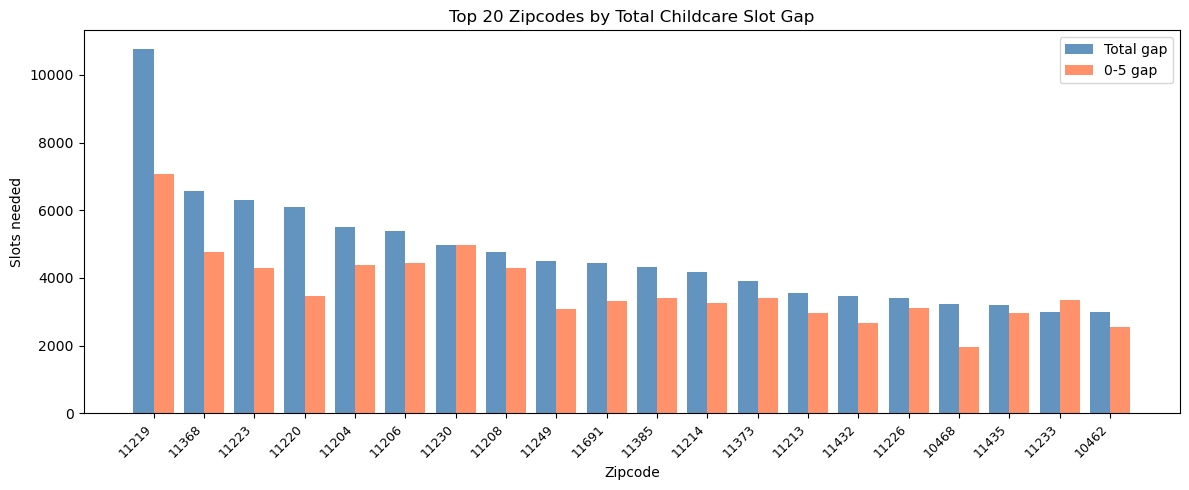

Figure saved: top20_gap.png


In [16]:
# ── Plot 1: Top 20 zipcodes by gap_total ───────────────────────────────────────
top20 = zip_df.nlargest(20, 'gap_total')[['zipcode','gap_total','gap_0_5']].reset_index(drop=True)
top20['zipcode'] = top20['zipcode'].astype(str)

fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(top20))
bars1 = ax.bar(x_pos - 0.2, top20['gap_total'], width=0.4, label='Total gap', color='steelblue', alpha=0.85)
bars2 = ax.bar(x_pos + 0.2, top20['gap_0_5'],   width=0.4, label='0-5 gap',   color='coral',     alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(top20['zipcode'], rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Zipcode')
ax.set_ylabel('Slots needed')
ax.set_title('Top 20 Zipcodes by Total Childcare Slot Gap')
ax.legend()
plt.tight_layout()
plt.savefig('top20_gap.png', dpi=120)
plt.show()
print("Figure saved: top20_gap.png")

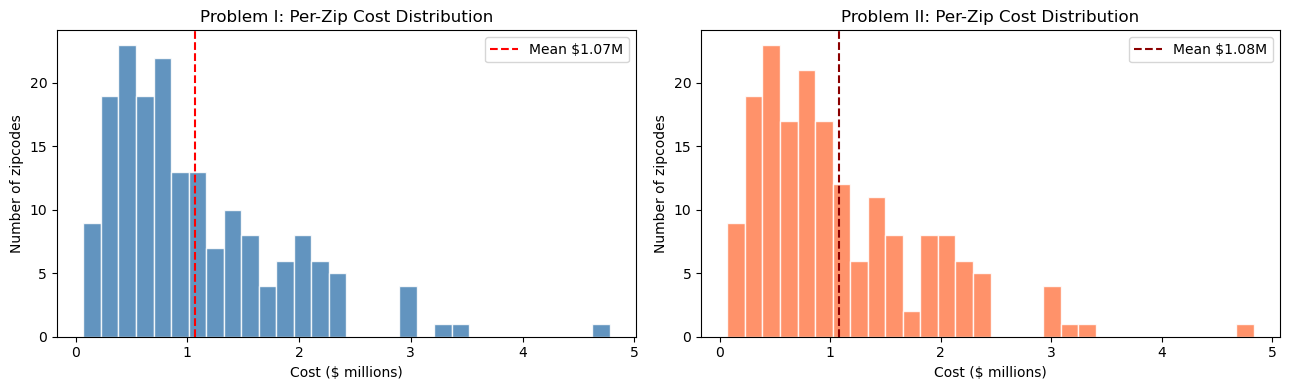

Figure saved: cost_histogram.png


In [17]:
# ── Plot 2: Histogram of per-zip costs ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

p1_nonzero = zip_df['cost_p1'].dropna()
p1_nonzero = p1_nonzero[p1_nonzero > 0]
axes[0].hist(p1_nonzero / 1e6, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Cost ($ millions)')
axes[0].set_ylabel('Number of zipcodes')
axes[0].set_title('Problem I: Per-Zip Cost Distribution')
axes[0].axvline(p1_nonzero.mean() / 1e6, color='red', linestyle='--', label=f'Mean ${p1_nonzero.mean()/1e6:.2f}M')
axes[0].legend()

p2_nonzero = zip_df['cost_p2'].dropna()
p2_nonzero = p2_nonzero[p2_nonzero > 0]
axes[1].hist(p2_nonzero / 1e6, bins=30, color='coral', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Cost ($ millions)')
axes[1].set_ylabel('Number of zipcodes')
axes[1].set_title('Problem II: Per-Zip Cost Distribution')
axes[1].axvline(p2_nonzero.mean() / 1e6, color='darkred', linestyle='--', label=f'Mean ${p2_nonzero.mean()/1e6:.2f}M')
axes[1].legend()

plt.tight_layout()
plt.savefig('cost_histogram.png', dpi=120)
plt.show()
print("Figure saved: cost_histogram.png")

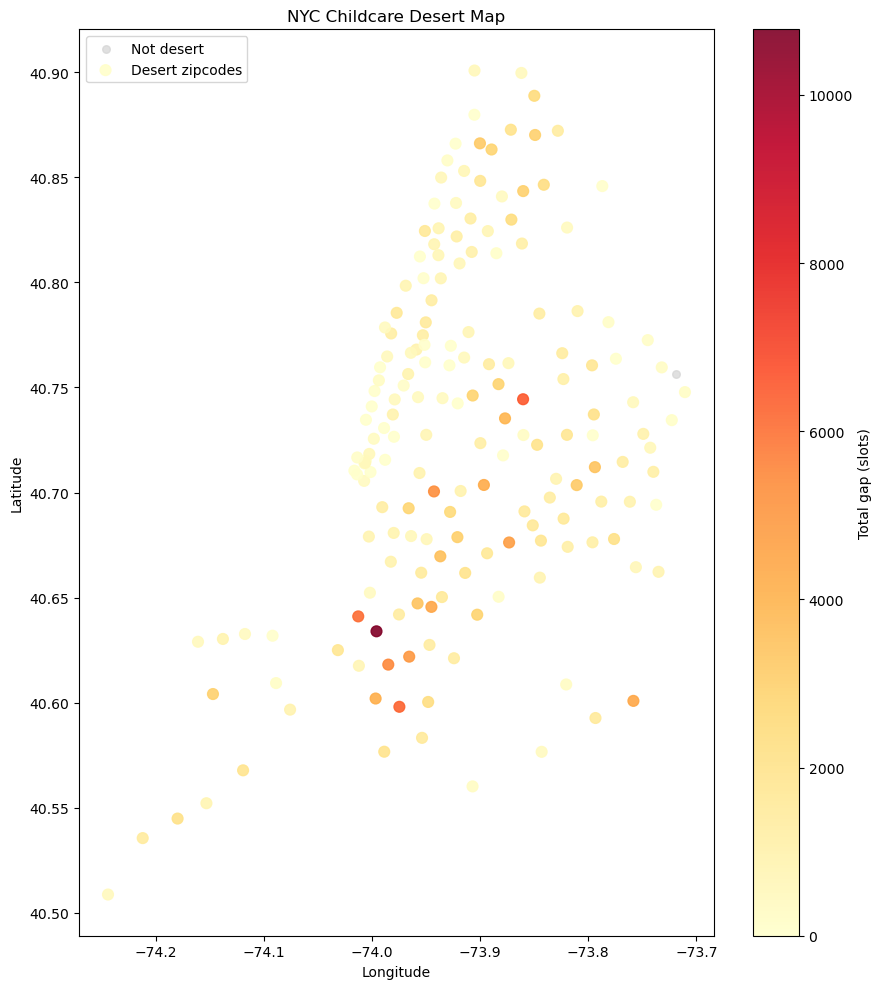

Figure saved: desert_map.png


In [18]:
# ── Plot 3: Scatter map of desert zipcodes ─────────────────────────────────────
# Use centroid of potential locations as proxy for zip lat/lon
zip_centroids = potential.groupby('zipcode')[['latitude','longitude']].mean().reset_index()
zip_map = zip_df.merge(zip_centroids, on='zipcode', how='left')

fig, ax = plt.subplots(figsize=(9, 10))
non_desert = zip_map[~zip_map['is_desert']]
desert     = zip_map[zip_map['is_desert']]

ax.scatter(non_desert['longitude'], non_desert['latitude'],
           c='lightgray', s=30, alpha=0.7, label='Not desert', zorder=2)
sc = ax.scatter(desert['longitude'], desert['latitude'],
                c=desert['gap_total'], cmap='YlOrRd', s=60, alpha=0.9,
                label='Desert zipcodes', zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Total gap (slots)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('NYC Childcare Desert Map')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('desert_map.png', dpi=120)
plt.show()
print("Figure saved: desert_map.png")

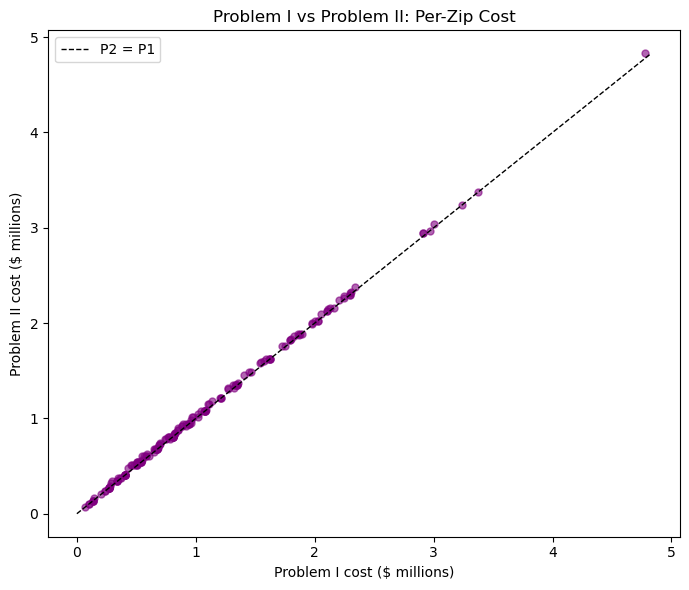

Figure saved: p1_vs_p2.png

=== Final Answer ===
Problem I  minimum total funding: $190,793,141
Problem II minimum total funding: $193,773,198


In [19]:
# ── Plot 4: P1 vs P2 cost comparison by zipcode (desert only) ─────────────────
desert_df = zip_df[zip_df['is_desert'] & zip_df['cost_p1'].notna() & zip_df['cost_p2'].notna()].copy()
desert_df = desert_df[(desert_df['cost_p1'] > 0) | (desert_df['cost_p2'] > 0)]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(desert_df['cost_p1'] / 1e6, desert_df['cost_p2'] / 1e6,
           alpha=0.6, c='purple', s=25)
lim_max = max(desert_df['cost_p1'].max(), desert_df['cost_p2'].max()) / 1e6
ax.plot([0, lim_max], [0, lim_max], 'k--', lw=1, label='P2 = P1')
ax.set_xlabel('Problem I cost ($ millions)')
ax.set_ylabel('Problem II cost ($ millions)')
ax.set_title('Problem I vs Problem II: Per-Zip Cost')
ax.legend()
plt.tight_layout()
plt.savefig('p1_vs_p2.png', dpi=120)
plt.show()
print("Figure saved: p1_vs_p2.png")

# Final summary printout
print("\n=== Final Answer ===")
print(f"Problem I  minimum total funding: ${total_p1:,.0f}")
print(f"Problem II minimum total funding: ${total_p2:,.0f}")